In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [4]:
from google.colab import files

uploaded = files.upload()

fake = pd.read_csv("/content/Fake.csv")
true = pd.read_csv("/content/True.csv")

fake["label"] = 0
true["label"] = 1

data = pd.concat([fake, true], ignore_index=True)

data = data.sample(frac=1, random_state=42).reset_index(drop=True)

print(data.head())
print("\nDataset Shape:", data.shape)
print("\nClass Distribution:")
print(data["label"].value_counts())

Saving True.csv to True (1).csv
Saving Fake.csv to Fake (1).csv
                                               title  \
0  Ben Stein Calls Out 9th Circuit Court: Committ...   
1  Trump drops Steve Bannon from National Securit...   
2  Puerto Rico expects U.S. to lift Jones Act shi...   
3   OOPS: Trump Just Accidentally Confirmed He Le...   
4  Donald Trump heads for Scotland to reopen a go...   

                                                text       subject  \
0  21st Century Wire says Ben Stein, reputable pr...       US_News   
1  WASHINGTON (Reuters) - U.S. President Donald T...  politicsNews   
2  (Reuters) - Puerto Rico Governor Ricardo Rosse...  politicsNews   
3  On Monday, Donald Trump once again embarrassed...          News   
4  GLASGOW, Scotland (Reuters) - Most U.S. presid...  politicsNews   

                  date  label  
0    February 13, 2017      0  
1       April 5, 2017       1  
2  September 27, 2017       1  
3         May 22, 2017      0  
4       June 24, 2

In [5]:
# Combine title and text
data["content"] = data["title"] + " " + data["text"]

# Features and labels
X = data["content"]
y = data["label"]

# Convert text into numerical features
vectorizer = TfidfVectorizer(stop_words="english", max_df=0.7)

X = vectorizer.fit_transform(X)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (35918, 122200)
Testing data shape: (8980, 122200)


In [6]:
# Train the model
model = PassiveAggressiveClassifier(max_iter=50)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy*100:.2f}%")

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 99.44%

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4710
           1       0.99      0.99      0.99      4270

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



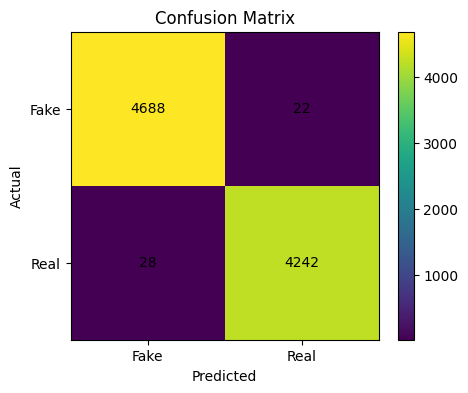

In [7]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0,1], ["Fake","Real"])
plt.yticks([0,1], ["Fake","Real"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [8]:
def predict_news(news):
    news_vector = vectorizer.transform([news])
    prediction = model.predict(news_vector)

    if prediction[0] == 0:
        return "📰 Fake News"
    else:
        return "✅ Real News"

news = input("Enter a news headline: ")
print(predict_news(news))

Enter a news headline: NASA confirms water found on Mars
📰 Fake News
